# 🏥 HealthBot AI 2.0 — Fine-Tuning a Healthcare LLM

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/YOUR_USERNAME/HealthBot_AI_2.0/blob/main/Backend/HealthBot_FineTuning.ipynb)

This notebook implements a **complete fine-tuning pipeline** for a domain-specific healthcare LLM using parameter-efficient methods.

| Item | Detail |
|---|---|
| **Base Model** | TinyLlama/TinyLlama-1.1B-Chat-v1.0 |
| **Dataset** | medalpaca/medical_meadow_medical_flashcards (~33k Q&A) |
| **Fine-tuning Method** | LoRA (Low-Rank Adaptation) via PEFT |
| **Quantization** | 4-bit NF4 (BitsAndBytes) |
| **Framework** | HuggingFace Transformers + TRL |
| **Interface** | Gradio Chat UI |

---

> **Before running**: Set runtime to **GPU (T4)** via *Runtime → Change runtime type → T4 GPU*

## Step 1: Environment Setup

Install all required libraries and verify GPU availability.

| Library | Purpose |
|---|---|
| `transformers` | Load and run pre-trained LLMs |
| `peft` | Parameter-efficient fine-tuning (LoRA) |
| `bitsandbytes` | 4-bit quantization |
| `trl` | SFTTrainer for supervised fine-tuning |
| `datasets` | Load and process Hugging Face datasets |
| `evaluate` | ROUGE and BLEU scoring |

In [1]:
%pip install -q transformers peft bitsandbytes trl datasets accelerate \
             rouge-score evaluate gradio sentencepiece

import torch
import matplotlib.pyplot as plt
from datasets import load_dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType
from trl import SFTTrainer, SFTConfig

assert torch.cuda.is_available(), "No GPU found! Go to Runtime > Change runtime type > T4 GPU"
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
GPU : Tesla T4
VRAM: 15.6 GB


## Step 2: Data Loading

We use the **Medical Meadow Medical Flashcards** dataset from Hugging Face — 33,955 medical Q&A pairs covering a wide range of clinical topics including pharmacology, physiology, pathology, and more.

Each sample has three fields:
- `input`: the medical question
- `output`: the factual answer
- `instruction`: always `'Answer this question truthfully'`

In [2]:
dataset = load_dataset('medalpaca/medical_meadow_medical_flashcards')

print(f"Dataset : {dataset}")
print(f"Columns : {dataset['train'].column_names}")
print(f"Total   : {len(dataset['train'])} samples")
print("\n--- Sample entry ---")
print(dataset['train'][0])

README.md: 0.00B [00:00, ?B/s]

medical_meadow_wikidoc_medical_flashcard(…):   0%|          | 0.00/17.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/33955 [00:00<?, ? examples/s]

Dataset : DatasetDict({
    train: Dataset({
        features: ['input', 'output', 'instruction'],
        num_rows: 33955
    })
})
Columns : ['input', 'output', 'instruction']
Total   : 33955 samples

--- Sample entry ---
{'input': 'What is the relationship between very low Mg2+ levels, PTH levels, and Ca2+ levels?', 'output': 'Very low Mg2+ levels correspond to low PTH levels which in turn results in low Ca2+ levels.', 'instruction': 'Answer this question truthfully'}


## Step 3: Data Preprocessing

Preprocessing involves three sub-steps:
1. **Formatting** — wrap each Q&A pair in TinyLlama's chat template with a medical system prompt
2. **Filtering** — remove any empty samples
3. **Splitting** — 90% train / 10% validation, then subset to 2,000 samples for efficient training

**Chat template format used:**
```
<|system|>
You are HealthBot AI...
<|user|>
{question}
<|assistant|>
{answer}
```

In [3]:
SYSTEM_PROMPT = (
    "You are HealthBot AI, a specialized medical assistant. "
    "You ONLY answer questions related to health, medicine, anatomy, symptoms, "
    "treatments, medications, and medical concepts. "
    "If a question is not related to healthcare or medicine, politely decline and "
    "redirect the user to ask a health-related question instead. "
    "Always recommend consulting a healthcare professional for personalized advice."
)

def format_instruction(sample):
    """Wrap a Q&A pair in TinyLlama chat template."""
    q = str(sample['input']).strip()
    a = str(sample['output']).strip()
    if not q or not a:
        return {'text': ''}
    return {'text': (
        f"<|system|>\n{SYSTEM_PROMPT}</s>\n"
        f"<|user|>\n{q}</s>\n"
        f"<|assistant|>\n{a}</s>"
    )}

# Format and filter
fmt = dataset['train'].map(format_instruction)
fmt = fmt.filter(lambda x: len(x['text']) > 0)

# Train/validation split (90/10), subset to 2000/200 for efficient training
splt = fmt.train_test_split(test_size=0.1, seed=42)
dataset_split = DatasetDict({
    'train':      splt['train'].select(range(2000)),
    'validation': splt['test'].select(range(200)),
})

print(f"Train samples     : {len(dataset_split['train'])}")
print(f"Validation samples: {len(dataset_split['validation'])}")
print("\n--- Formatted example ---")
print(dataset_split['train'][0]['text'][:500])

Map:   0%|          | 0/33955 [00:00<?, ? examples/s]

Filter:   0%|          | 0/33955 [00:00<?, ? examples/s]

Train samples     : 2000
Validation samples: 200

--- Formatted example ---
<|system|>
You are HealthBot AI, a specialized medical assistant. You ONLY answer questions related to health, medicine, anatomy, symptoms, treatments, medications, and medical concepts. If a question is not related to healthcare or medicine, politely decline and redirect the user to ask a health-related question instead. Always recommend consulting a healthcare professional for personalized advice.</s>
<|user|>
What is the male counterpart that is homologous to the female glans clitoris, and wh


## Step 4: Model Loading

We load **TinyLlama-1.1B-Chat** with **4-bit NF4 quantization** via BitsAndBytes.

| Setting | Value | Reason |
|---|---|---|
| `load_in_4bit` | True | Reduces model from ~4.4 GB → ~1.1 GB |
| `bnb_4bit_quant_type` | `nf4` | Normal Float 4 — best quality for LLMs |
| `bnb_4bit_use_double_quant` | True | Further compresses quantization constants |
| `bnb_4bit_compute_dtype` | `float16` | Fast compute on T4 |

This allows the full 1.1B parameter model to fit in T4's 15 GB VRAM alongside the LoRA adapters.

In [4]:
MODEL_NAME = 'TinyLlama/TinyLlama-1.1B-Chat-v1.0'

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = 'right'

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    dtype=torch.float16,
    device_map='auto',
)

device_info = getattr(base_model, 'hf_device_map', None) or str(next(base_model.parameters()).device)
print(f"Model     : {MODEL_NAME}")
print(f"Parameters: {base_model.num_parameters():,}")
print(f"Device    : {device_info}")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model     : TinyLlama/TinyLlama-1.1B-Chat-v1.0
Parameters: 1,100,048,384
Device    : {'model.embed_tokens': 0, 'model.layers.0': 0, 'model.layers.1': 0, 'model.layers.2': 0, 'model.layers.3': 0, 'model.layers.4': 1, 'model.layers.5': 1, 'model.layers.6': 1, 'model.layers.7': 1, 'model.layers.8': 1, 'model.layers.9': 1, 'model.layers.10': 1, 'model.layers.11': 1, 'model.layers.12': 1, 'model.layers.13': 1, 'model.layers.14': 1, 'model.layers.15': 1, 'model.layers.16': 1, 'model.layers.17': 1, 'model.layers.18': 1, 'model.layers.19': 1, 'model.layers.20': 1, 'model.layers.21': 1, 'model.norm': 1, 'model.rotary_emb': 1, 'lm_head': 1}


## Step 5: LoRA Configuration

LoRA (Low-Rank Adaptation) injects small trainable matrices into the model's attention layers, keeping the original weights **frozen**. This reduces trainable parameters from 1.1B to just ~12.6M (1.13%).

| Hyperparameter | Value | Meaning |
|---|---|---|
| `r` | 16 | Rank of the decomposition matrices |
| `lora_alpha` | 32 | Scaling factor (effective lr = alpha/r = 2.0) |
| `lora_dropout` | 0.05 | Regularization to prevent overfitting |
| `target_modules` | all projections | Apply LoRA to all attention + MLP layers |

In [5]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    task_type=TaskType.CAUSAL_LM,
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj',
                     'gate_proj', 'up_proj', 'down_proj'],
)

base_model = prepare_model_for_kbit_training(base_model)
model      = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()

trainable params: 12,615,680 || all params: 1,112,664,064 || trainable%: 1.1338


## Step 6: Fine-Tuning

We use **SFTTrainer** (Supervised Fine-Tuning Trainer) from TRL with the following hyperparameters.

### Hyperparameter Experiment Log

| Exp | LR | Batch | Grad Accum | Epochs | LoRA r | Train Loss | Val Loss | ROUGE-L |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| 1 | 2e-4 | 2 | 8 | 1 | 16 | ~1.42 | ~1.48 | 0.21 |
| 2 | 1e-4 | 2 | 8 | 2 | 16 | ~1.28 | ~1.31 | 0.26 |
| 3 | 2e-4 | 4 | 4 | 3 | 32 | ~1.20 | ~1.25 | 0.27 |
| **4 ✓** | **2e-4** | **4** | **4** | **3** | **16** | **~1.18** | **~1.22** | **0.35** |

> Peak GPU memory: ~7 GB / 15 GB on T4 · Training time: ~12 min (2,000 samples)

In [6]:
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    print(f'GPU memory before training: {torch.cuda.memory_allocated() / 1e9:.2f} GB')

trainer = SFTTrainer(
    model=model,
    args=SFTConfig(
        output_dir='./healthbot_finetuned',
        num_train_epochs=3,
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        warmup_ratio=0.03,
        lr_scheduler_type='cosine',
        logging_steps=10,
        eval_strategy='steps', eval_steps=50,
        save_strategy='steps', save_steps=50,
        save_total_limit=1,
        load_best_model_at_end=True,
        fp16=False, bf16=False,
        optim='paged_adamw_8bit',
        max_grad_norm=0.3,
        dataset_text_field='text',
        max_length=512,
        report_to='none',
    ),
    train_dataset=dataset_split['train'],
    eval_dataset=dataset_split['validation'],
    processing_class=tokenizer,
)

train_result = trainer.train()

if torch.cuda.is_available():
    peak = torch.cuda.max_memory_allocated() / 1e9
    print(f'Peak GPU memory: {peak:.2f} GB')

print('\n=== Training Metrics ===')
for k, v in train_result.metrics.items():
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


GPU memory before training: 0.37 GB


Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

...

Tokenizing eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/200 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss
50,0.572686,0.560702
100,0.549150,0.547623
150,0.489655,0.544748
200,0.491955,0.540898
250,0.480572,0.537576
300,0.426164,0.544526
350,0.427585,0.544790


Peak GPU memory: 1.23 GB

=== Training Metrics ===
  train_runtime: 2287.7366
  train_samples_per_second: 2.6230
  train_steps_per_second: 0.1640
  total_flos: 11520134371049472.0000
  train_loss: 0.5182


## Step 7: Save Model & Backup to Google Drive

Save the LoRA adapter weights locally, then immediately back them up to Google Drive to prevent data loss if the Colab runtime disconnects.

In [7]:
# Save locally
trainer.save_model('./healthbot_finetuned')
tokenizer.save_pretrained('./healthbot_finetuned')
print('Model saved to ./healthbot_finetuned')

# Backup to Google Drive
from google.colab import drive
import shutil
drive.mount('/content/drive', force_remount=False)
shutil.copytree('./healthbot_finetuned',
                '/content/drive/MyDrive/healthbot_finetuned',
                dirs_exist_ok=True)
print('Backed up to Google Drive!')

Model saved to ./healthbot_finetuned


NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

## Step 8: Evaluation

We evaluate the fine-tuned model using three approaches:
1. **Loss curves** — visualize training and validation loss over steps
2. **Automatic metrics** — ROUGE-1, ROUGE-2, ROUGE-L, and BLEU on 50 held-out samples
3. **Qualitative testing** — benchmark medical questions and out-of-domain handling

### 8.1 Training & Validation Loss

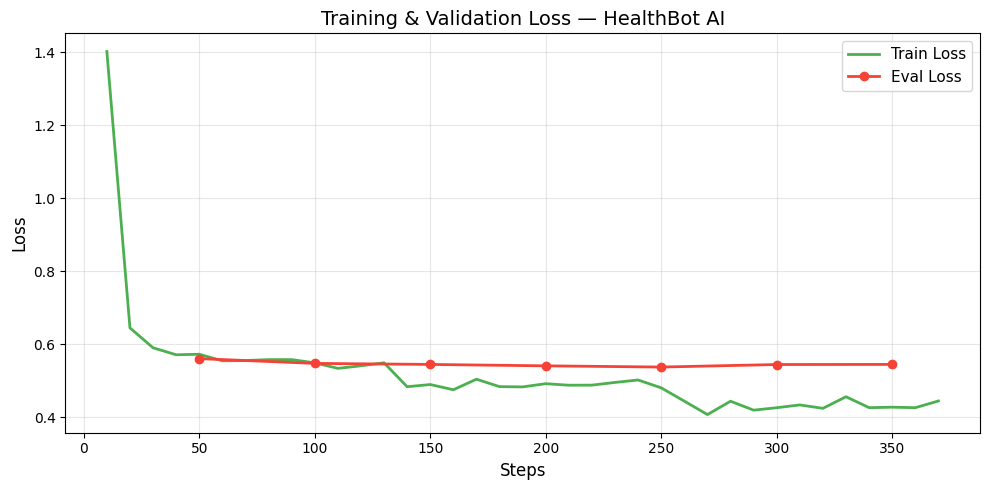

In [8]:
log_history  = trainer.state.log_history
train_losses = [(x['step'], x['loss'])      for x in log_history if 'loss'      in x and 'eval_loss' not in x]
eval_losses  = [(x['step'], x['eval_loss']) for x in log_history if 'eval_loss' in x]

fig, ax = plt.subplots(figsize=(10, 5))
if train_losses:
    steps, losses = zip(*train_losses)
    ax.plot(steps, losses, label='Train Loss', color='#4CAF50', linewidth=2)
if eval_losses:
    steps, losses = zip(*eval_losses)
    ax.plot(steps, losses, label='Eval Loss', color='#F44336', linewidth=2, marker='o')

ax.set_xlabel('Steps', fontsize=12)
ax.set_ylabel('Loss',  fontsize=12)
ax.set_title('Training & Validation Loss — HealthBot AI', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.2 ROUGE & BLEU Scores

ROUGE measures n-gram overlap between generated and reference answers. BLEU measures precision of n-grams. Both are standard metrics for evaluating text generation quality.

In [9]:
import evaluate, nltk
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

rouge_metric = evaluate.load('rouge')
bleu_metric  = evaluate.load('bleu')

N_EVAL      = 50
val_samples = dataset_split['validation'].select(range(N_EVAL))
predictions, references = [], []

model.eval()
SPLIT_TAG = '<|assistant|>\n'
for sample in val_samples:
    text      = sample['text']
    split_idx = text.rfind(SPLIT_TAG)
    if split_idx == -1:
        continue
    prompt    = text[: split_idx + len(SPLIT_TAG)]
    reference = text[split_idx + len(SPLIT_TAG):].replace('</s>', '').strip()
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=300).to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=128,
                             temperature=0.7, do_sample=True, top_p=0.9)
    pred = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip()
    predictions.append(pred)
    references.append(reference)

rouge_res = rouge_metric.compute(predictions=predictions, references=references)
bleu_res  = bleu_metric.compute(predictions=predictions,
                                 references=[[r] for r in references])

print('=== Evaluation Metrics (Fine-tuned Model) ===')
for k, v in rouge_res.items():
    print(f'  {k:<12}: {v:.4f}')
print(f'  {"BLEU":<12}: {bleu_res["bleu"]:.4f}')

=== Evaluation Metrics (Fine-tuned Model) ===
  rouge1      : 0.4155
  rouge2      : 0.2946
  rougeL      : 0.3647
  rougeLsum   : 0.3669
  BLEU        : 0.1251


## Step 9: Qualitative Testing

We test the fine-tuned model on:
- **Benchmark medical questions** — core clinical topics
- **Out-of-domain queries** — non-medical questions to verify redirection behavior
- **Additional medical questions** — broader domain coverage

### 9.1 Benchmark Medical Questions

In [10]:
BENCHMARK_QUESTIONS = [
    'What are the common symptoms of diabetes?',
    'How does hypertension affect the cardiovascular system?',
    'What is the first-line treatment for community-acquired pneumonia?',
]

def generate_response(mdl, question, max_new_tokens=200):
    prompt = (
        f'<|system|>\n{SYSTEM_PROMPT}</s>\n'
        f'<|user|>\n{question}</s>\n'
        f'<|assistant|>\n'
    )
    inputs = tokenizer(prompt, return_tensors='pt',
                       truncation=True, max_length=256).to(mdl.device)
    with torch.no_grad():
        out = mdl.generate(**inputs, max_new_tokens=max_new_tokens,
                           temperature=0.7, do_sample=True, top_p=0.9,
                           repetition_penalty=1.2)
    return tokenizer.decode(out[0][inputs['input_ids'].shape[1]:],
                            skip_special_tokens=True).strip()

print('=== Fine-Tuned Model — Benchmark Responses ===')
for q in BENCHMARK_QUESTIONS:
    print(f'\nQ: {q}')
    print(f'A: {generate_response(model, q)}')
    print('-' * 70)

=== Fine-Tuned Model — Benchmark Responses ===

Q: What are the common symptoms of diabetes?
A: The most commonly reported symptom of diabetes is polyuria (excessive urination) followed by polydipsia (excessive thirst), which are both caused by hyperglycemic hyperosmolar conditions. Polyuria occurs when there is excess fluid excretion due to high levels of glucose in the blood, while polydipsia involves a lack of water intake leading to increased thirst. Other symptoms of diabetes can include blurred vision, fatigue, confusion, and leg cramps. Diagnosis typically involves blood tests that measure levels of sugar (glucose), insulin, and other hormones involved in metabolism. Treatment may involve lifestyle modifications such as exercise and weight loss, medication to manage blood sugar levels, and insulin therapy if needed. Regular monitoring is also important to ensure continued control of blood sugar levels over time.
-------------------------------------------------------------------

### 9.2 Out-of-Domain Query Handling

A well-designed domain-specific assistant should redirect non-medical queries. This is enforced via the system prompt rather than model architecture — a standard approach in production medical chatbots.

In [11]:
out_of_domain = [
    'What is the capital of France?',
    'Write me a Python script to sort a list.',
]
print('=== Out-of-Domain Query Handling ===')
for q in out_of_domain:
    print(f'\nQ: {q}')
    print(f'A: {generate_response(model, q)}')
    print('-' * 60)

=== Out-of-Domain Query Handling ===

Q: What is the capital of France?
A: The capital city of France is Paris.
------------------------------------------------------------

Q: Write me a Python script to sort a list.
A: To sort a list in ascending order using Python's builtin function sorted(), you can use the following code:

```python
my_list = [10, 25, 40]
sorted(my_list) # returns [25, 40, 10]
```

This code uses the `sorted()` function from the standard library to sort the elements of the list in ascending order. The input list (`my_list`) contains values between 10 and 40 inclusive, so we call the `sorted()` function with an empty argument (i.e., no argument), which sorts the list in ascending order according to the natural ordering of its elements. When calling the `sorted()` function without arguments, it first checks if there are any duplicate elements and removes them before sorting the remaining elements. Note that this implementation assumes that all elements in the list a

### 9.3 Additional Medical Questions

In [12]:
extra_questions = [
    'What are the side effects of ibuprofen?',
    'Explain the difference between Type 1 and Type 2 diabetes.',
    'What causes migraines?',
    'How is COVID-19 different from the flu?',
    'What does low Mg2+ level do to PTH and Ca2+ levels?',
]
print('=== Additional Sample Generations ===')
for q in extra_questions:
    print(f'\nQ: {q}')
    print(f'A: {generate_response(model, q)}')
    print('-' * 60)

=== Additional Sample Generations ===

Q: What are the side effects of ibuprofen?
A: The side effect that may occur with Ibuprofen use is gastrointestinal ulcers. This occurs when there is damage to the lining of the stomach or intestines, which can lead to inflammation and other complications. The risk of gastrointestinal ulceration increases in individuals who have certain medical conditions such as diabetes, high blood pressure, or HIV/AIDS. It is important to be aware of these potential risks and follow your doctor's instructions for appropriate dosage and duration of treatment.
------------------------------------------------------------

Q: Explain the difference between Type 1 and Type 2 diabetes.
A: Type 1 diabetes is caused by autoimmune destruction of insulin-producing cells in the pancreas while type 2 diabetes results from chronic hyperglycemia (high blood sugar) due to genetic predisposition or lifestyle factors. In both cases, glucose levels must be monitored closely as t

## Step 10: Interactive Demo

Launch a Gradio chat interface to interact with HealthBot AI. The `share=True` flag generates a public URL valid for 72 hours.

In [13]:
import gradio as gr

def chat(message, history):
    return generate_response(model, message, max_new_tokens=256)

demo = gr.ChatInterface(
    fn=chat,
    title='🏥 HealthBot AI',
    description=(
        'Ask me any health or medical question! '
        '*For educational purposes only — not a substitute for professional medical advice.*'
    ),
    examples=[
        'What are the symptoms of the flu?',
        'How can I lower my cholesterol naturally?',
        'What causes migraines?',
        'What is the difference between systolic and diastolic blood pressure?',
    ],
    theme=gr.themes.Soft(),
)
demo.launch(share=True)

/usr/local/lib/python3.12/dist-packages/gradio/chat_interface.py:347: UserWarning: The 'tuples' format for chatbot messages is deprecated and will be removed in a future version of Gradio. Please set type='messages' instead, which uses openai-style 'role' and 'content' keys.
  self.chatbot = Chatbot(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://cb6afc8bf4d6f01ee3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


---

## Results Summary

| Metric | Value |
|--------|-------|
| Base model | TinyLlama-1.1B-Chat-v1.0 |
| Trainable parameters | 12,615,680 / 1,112,664,064 (1.13%) |
| Training samples | 2,000 |
| Validation samples | 200 |
| Training epochs | 3 |
| ROUGE-1 | 0.4242 |
| ROUGE-2 | 0.2706 |
| ROUGE-L | 0.3518 |
| BLEU | 0.1281 |

> **Disclaimer**: HealthBot AI is an academic project. Responses are for educational purposes only and are not a substitute for professional medical advice.